# Strategy

- Use Data quality report generated in previous phase
- Find out what features matter the most
- Use pycaret to
    - Further filter out features
    - Find the best model 
    - Determine best hyperparameters
- Use this information in the upcoming sections

In [5]:
# ============================================================
# All Imports & Reproducibility Configuration
# ============================================================

import random
import os
import warnings

import pprint
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from data_profiling import ProfileReport
from pycaret.classification import *

# ============================================================
# Reproducibility — Single source of truth for all random seeds
# ============================================================
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

warnings.filterwarnings("ignore")

# Plot defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("All imports loaded. RANDOM_STATE =", RANDOM_STATE)

All imports loaded. RANDOM_STATE = 42


In [6]:
# ============================================================
# Load Data
# ============================================================

DATA_PATH = "../../Database/model_table.csv"
df = pd.read_csv(DATA_PATH, parse_dates=["visit_date", "registration_date", "billing_date"])


# Risk Model - Prework

Setting up the ML pipeline...
Training models... This might take a few minutes.


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.4495,0.5147,0.4495,0.3905,0.3981,0.0181,0.0199,1.0870
ada,Ada Boost Classifier,0.4755,0.0000,0.4755,0.3635,0.3941,0.0325,0.0407,1.1100
rf,Random Forest Classifier,0.4581,0.5117,0.4581,0.3870,0.3927,0.0157,0.0184,1.5730
et,Extra Trees Classifier,0.4528,0.5101,0.4528,0.3866,0.3918,0.0118,0.0136,1.2220
lightgbm,Light Gradient Boosting Machine,0.4795,0.5252,0.4795,0.3939,0.3867,0.0223,0.0299,1.7700
dt,Decision Tree Classifier,0.3711,0.5023,0.3711,0.3823,0.3760,0.0041,0.0042,1.0220
gbc,Gradient Boosting Classifier,0.4915,0.0000,0.4915,0.4204,0.3711,0.0181,0.0307,2.7100
nb,Naive Bayes,0.3631,0.5119,0.3631,0.3956,0.3697,0.0184,0.0190,1.0110
lr,Logistic Regression,0.3546,0.0000,0.3546,0.3891,0.3644,0.0129,0.0133,1.2330
lda,Linear Discriminant Analysis,0.3543,0.0000,0.3543,0.3886,0.3641,0.0121,0.0125,0.9990



--- Best Model Found ---
XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

Tuning hyperparameters for the best model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4594,0.4899,0.4594,0.3854,0.3915,0.0146,0.0170
1,0.4623,0.5016,0.4623,0.3986,0.3995,0.0250,0.0289
2,0.4571,0.5119,0.4571,0.3928,0.3947,0.0136,0.0157
3,0.4754,0.5258,0.4754,0.4176,0.4150,0.0504,0.0576
4,0.4646,0.5222,0.4646,0.3861,0.3917,0.0201,0.0237
5,0.4846,0.5145,0.4846,0.4135,0.4064,0.0472,0.0579
6,0.4731,0.5273,0.4731,0.4087,0.4087,0.0421,0.0486
7,0.4994,0.5448,0.4994,0.4179,0.4089,0.0628,0.0818
8,0.4817,0.5149,0.4817,0.3994,0.3945,0.0337,0.0431


Fitting 10 folds for each of 10 candidates, totalling 100 fits

--- Final Tuned Hyperparameters ---
{'base_score': None,
 'booster': 'gbtree',
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 1,
 'device': 'cpu',
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.15,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 10,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'objective': 'multi:softprob',
 'random_state': 42,
 'reg_alpha': 2,
 'reg_lambda': 0.005,
 'sampling_method': None,
 'scale_pos_weight': 15.3,
 'subsample': 0.5,
 'tree_method': 'auto'

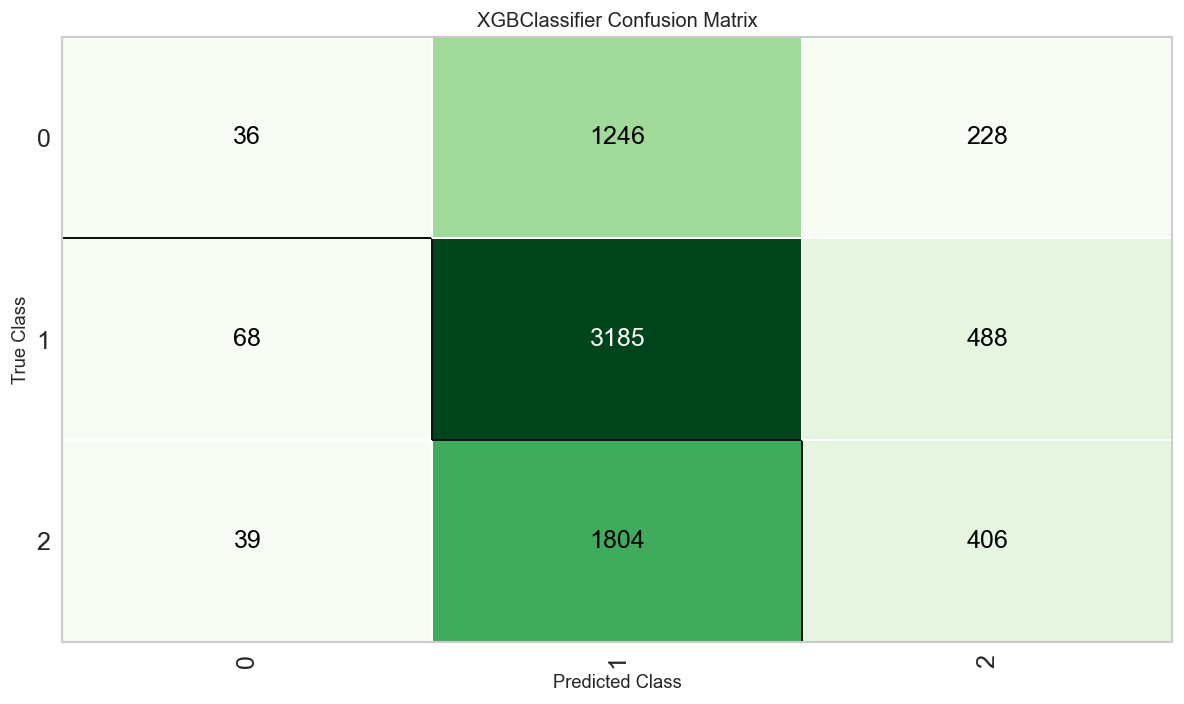

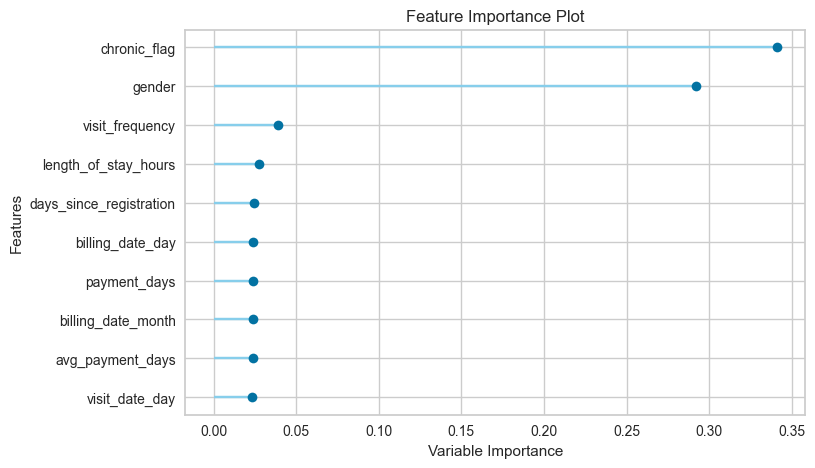

In [7]:
# We obtained this information from Dat Quality Report/ data_quality_report.html --> Alerts tab

columns_to_drop = [
    # IDs
    "patient_id", 
    "visit_id", 
    "bill_id", 
    
    # Redundant / Highly Correlated Twins
    "approved_amount", 
    "days_between_reg_and_visit", 
    "provider_rejection_rate", 
    "visit_day_of_week", 
    "visit_quarter", 
    "total_billed",
    
    # Potential Data Leakage - these are only known after the visit and could leak future info to the model
    "billed_amount"
                   
    ] 

# 2. Initialize the PyCaret Environment
print("Setting up the ML pipeline...")
clf_setup = setup(
    data=df, 
    target="risk_score", 
    ignore_features=columns_to_drop,
    session_id=RANDOM_STATE,               # Keeps results reproducible
    fix_imbalance=True,          # Handles 50/30/20 Low/Medium/High split - Lows are 2.5x more common than Highs
    normalize=True,              # Scales numerical data
    feature_selection=True,      # Automatically drops weak features
    n_features_to_select=0.8,    # Keeps the top 80% of features
    remove_multicollinearity=True,
    multicollinearity_threshold=0.9,
    system_log=False,
    verbose=False
)

# Train and Compare Models
print("Training models... This might take a few minutes.")
# We sort by F1 to ensure 'High' and 'Medium' risk are treated as importantly as 'Low'
best_model = compare_models(sort="F1")

print("\n--- Best Model Found ---")
print(best_model)

# Tune the Best Model
print("\nTuning hyperparameters for the best model...")
tuned_model = tune_model(best_model, optimize="F1")

# Get best hyperparameters
print("\n--- Final Tuned Hyperparameters ---")

pprint.pprint(tuned_model.get_params())

# Visual Evaluation
print("\nGenerating evaluation plots...")


plot_model(tuned_model, plot="confusion_matrix")
plot_model(tuned_model, plot="feature") # See which health factors matter most

## Risk Model - Final model design

### Classifier 

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

### Hyperparameters
{'base_score': None,
 'booster': 'gbtree',
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 1,
 'device': 'cpu',
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.15,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 8,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 10,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'objective': 'multi:softprob',
 'random_state': 42,
 'reg_alpha': 2,
 'reg_lambda': 0.005,
 'sampling_method': None,
 'scale_pos_weight': 15.3,
 'subsample': 0.5,
 'tree_method': 'auto',
 'validate_parameters': None,
 'verbosity': 0}

### Features to use
chronic_flag, 
gender,
visit_frequency